In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [20]:
np.random.seed(42)

number_of_students = 500

study_hours = np.random.uniform(1, 10, number_of_students)
attendance = np.random.uniform(60, 100, number_of_students)
previous_score = np.random.uniform(40, 100, number_of_students)

final_score = (20 
        + 3.5 * study_hours 
        + 0.25 * attendance
        + 0.45 * previous_score
        + np.random.normal(0, 5, number_of_students))

final_score = np.clip(final_score, 0, 100)

df = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "previous_score": previous_score,
    "final_score": final_score
})
df.head()

,study_hours,attendance,previous_score,final_score
0,4.370861,87.926469,51.107976,67.781191
1,9.556429,81.443855,72.514057,100.000000
2,7.587945,72.381105,92.376750,99.274761
3,6.387926,92.551801,83.933493,95.038771
4,2.404168,87.389247,88.393669,95.151902


## Inspect the dataset

In [19]:
df.shape
df.info()
df.describe()

df.to_csv("../data/student_scores.csv", index=False)


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     500 non-null    float64
 1   attendance      500 non-null    float64
 2   previous_score  500 non-null    float64
 3   final_score     500 non-null    float64
dtypes: float64(4)
memory usage: 15.8 KB


## Visualize the data

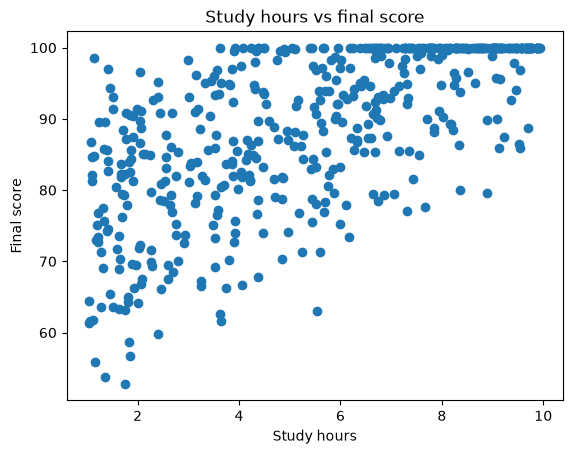

In [27]:
plt.scatter(df["study_hours"], df["final_score"])

plt.xlabel("Study hours")
plt.ylabel("Final score")
plt.title("Study hours vs final score")

plt.show()

## Split the data

In [28]:
X = df[["study_hours", "attendance", "previous_score"]]
y = df["final_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train the model

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[2.64,0.22,0.35]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['study_hours','attendance','previous_score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,31.96
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


## Evaluate

In [30]:
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 25.623856200858036
RMSE: 5.0620012051418986
R²: 0.7659587808291801


## TEST

In [31]:
student = pd.DataFrame({
    "study_hours": [8],
    "attendance": [92],
    "previous_score": [78]
})

predicted_score = model.predict(student)[0]
predicted_score = max(0, min(100, predicted_score))

print(f"Predicted final score: {predicted_score:.2f}")

Predicted final score: 100.00


In [32]:
comparison = pd.DataFrame({
    "actual_score": y_test,
    "predicted_score": predictions
})

comparison["error"] = (
    comparison["actual_score"] - comparison["predicted_score"]
)

comparison.head(10)

,actual_score,predicted_score,error
361,89.894835,85.320019,4.574816
73,100.000000,86.792573,13.207427
374,63.341362,68.802816,-5.461454
155,79.164712,84.435343,-5.270631
104,100.000000,105.307655,-5.307655
394,81.882854,82.662552,-0.779698
377,75.058870,78.800074,-3.741205
124,83.624092,86.280333,-2.656241
68,82.284126,78.750578,3.533548
450,98.949959,95.831912,3.118047


In [33]:
comparison["absolute_error"] = comparison["error"].abs()

comparison.sort_values("absolute_error", ascending=False).head(10)

,actual_score,predicted_score,error,absolute_error
73,100.000000,86.792573,13.207427,13.207427
131,98.302107,85.165885,13.136222,13.136222
0,67.781191,80.512354,-12.731163,12.731163
371,55.825615,68.264446,-12.438831,12.438831
76,100.000000,89.385901,10.614099,10.614099
79,96.523254,86.738340,9.784915,9.784915
431,88.151228,97.876467,-9.725239,9.725239
324,100.000000,109.631445,-9.631445,9.631445
334,96.962726,87.679479,9.283247,9.283247
11,100.000000,109.208407,-9.208407,9.208407
